In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import medfilt
import os
from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Baskerville']

In [22]:
data_directory = "/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2_1/week2/Similar_FOV_ts/test"
output_dir = "/Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2_1/week2/Similar_FOV_ts_darkfix_npz/test"
os.makedirs(output_dir, exist_ok= True)

In [23]:

n_npy = sum(
    1 for f in os.listdir(data_directory)
    if f.lower().endswith(".npz") and os.path.isfile(os.path.join(data_directory, f))
)

print("Number of .npz files:", n_npy)

Number of .npz files: 1


Number of .npz files: 1
Shape ts_Bef: (203, 841)
Test2_Week_2_2022_09_01_12_12_05_Fluo17012_CS1A1S1_ts_labels.npz: dark frames detected = 1


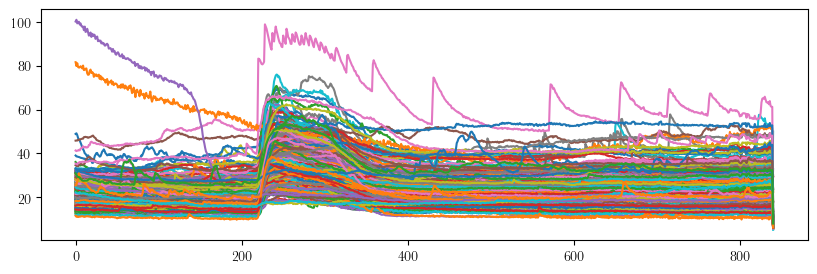

Shape ts_Aft: (203, 841)


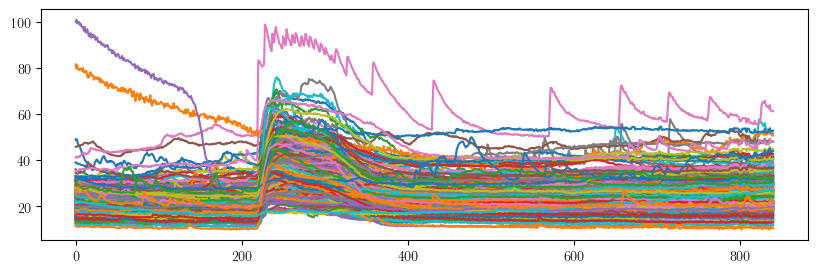

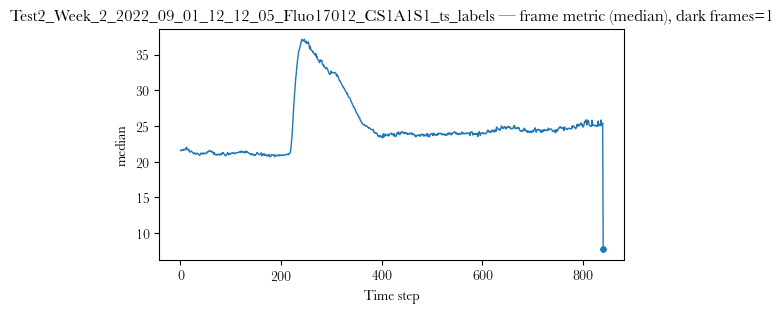

Done. Fixed .npz files saved in: /Volumes/DATA/DHM 1082/yaza3022/hIPSC/Schizopherenic_iPSCs/Fluo/Test2_1/week2/Similar_FOV_ts_darkfix_npz/test


In [26]:
#npz file
# ----------------------------
# Dark-frame detection + fix
# ----------------------------
def detect_dark_frames(Ts, z_thresh=6.0, metric="median", only_dark=True):
    Ts = np.asarray(Ts)
    if metric == "median":
        frame_metric = np.nanmedian(Ts, axis=0)
    elif metric == "mean":
        frame_metric = np.nanmean(Ts, axis=0)
    else:
        raise ValueError("metric must be 'median' or 'mean'")

    med = np.nanmedian(frame_metric)
    mad = np.nanmedian(np.abs(frame_metric - med)) + 1e-12
    robust_z = 0.6745 * (frame_metric - med) / mad

    bad_mask = (robust_z < -z_thresh) if only_dark else (np.abs(robust_z) > z_thresh)
    return bad_mask, frame_metric, robust_z

def replace_bad_frames_with_interp(Ts, bad_mask):
    Ts = np.asarray(Ts)
    N, T = Ts.shape
    x = np.arange(T)
    good = ~bad_mask
    if good.sum() < 2:
        return Ts.copy()

    Ts_fixed = Ts.copy()
    xg = x[good]
    for i in range(N):
        Ts_fixed[i, :] = np.interp(x, xg, Ts[i, good])
    return Ts_fixed

# ----------------------------
# NPZ-safe runner:
# - loads npz with keys: ts, labels, movie_path, mask_path (any subset)
# - fixes ts only
# - saves NEW npz preserving ALL original keys + exact order
# - checks that labels and shape are unchanged
# ----------------------------
def run_darkfix_on_npz_folder(
    data_directory,
    output_dir,
    z_thresh=6.0,
    metric="median",
    only_dark=True,
    preview_files=0,
    preview_neurons=10,
    suffix="_darkfix",
):
    os.makedirs(output_dir, exist_ok=True)

    npz_files = sorted([f for f in os.listdir(data_directory) if f.lower().endswith(".npz")])
    print("Number of .npz files:", len(npz_files))

    for k, fname in enumerate(npz_files):
        in_path = os.path.join(data_directory, fname)
        base = os.path.splitext(fname)[0]

        z = np.load(in_path, allow_pickle=True)
        keys = list(z.files)

        if "ts" not in keys:
            print(f"Skipping {fname} (no 'ts' key). Keys={keys}")
            z.close()
            continue

        Ts = z["ts"]
        print("Shape ts_Bef:",np.shape(Ts))
        Ts = Ts.astype(np.float32, copy=True)

        # Keep a copy for verification
        Ts0_shape = Ts.shape
        labels0 = None
        if "labels" in keys:
            labels0 = np.array(z["labels"], copy=True)

        bad_mask, frame_metric, rz = detect_dark_frames(Ts, z_thresh=z_thresh, metric=metric, only_dark=only_dark)
        bad_idx = np.where(bad_mask)[0]
        print(f"{fname}: dark frames detected = {len(bad_idx)}")
        plt.figure(figsize=(9.9,3))
        plt.plot(Ts.T)
        plt.show()

        Ts_fixed = replace_bad_frames_with_interp(Ts, bad_mask)
        print("Shape ts_Aft:",np.shape(Ts_fixed))
        plt.figure(figsize=(9.9,3))
        plt.plot(Ts_fixed.T)
        plt.show()

        # ----------------------------
        # Verification: no displacement / removal
        # ----------------------------
        if Ts_fixed.shape != Ts0_shape:
            raise RuntimeError(f"Shape changed for {fname}: {Ts0_shape} -> {Ts_fixed.shape}")

        if labels0 is not None:
            labels1 = np.array(z["labels"], copy=True)  # from original file
            if labels1.shape != labels0.shape or not np.array_equal(labels1, labels0):
                raise RuntimeError(f"Labels changed for {fname} (should never happen).")

        # Build output dict preserving ALL original keys (same values), replacing only ts
        out_dict = {}
        for key in keys:
            if key == "ts":
                out_dict["ts"] = Ts_fixed.astype(np.float32)
            else:
                out_dict[key] = z[key]  # keep as-is

        z.close()

        out_path = os.path.join(output_dir, base + suffix + ".npz")
        np.savez(out_path, **out_dict)

#         ----------------------------
#         Optional previews
#         ----------------------------
        if k < preview_files:
            plt.figure(figsize=(6, 3))
            plt.plot(frame_metric, linewidth=1)
            if len(bad_idx) > 0:
                plt.scatter(bad_idx, frame_metric[bad_idx], s=15)
            plt.title(f"{base} — frame metric ({metric}), dark frames={len(bad_idx)}")
            plt.xlabel("Time step")
            plt.ylabel(metric)
            plt.show()

            n_show = min(preview_neurons, Ts.shape[0])
            neuron_ids = np.linspace(0, Ts.shape[0]-1, n_show, dtype=int)

#             plt.figure(figsize=(6, 3))
#             for i2 in neuron_ids:
#                 plt.plot(Ts[i2], linewidth=0.7)
#             plt.title(f"{base} — BEFORE (sample neurons)")
#             plt.xlabel("Time step")
#             plt.show()

#             plt.figure(figsize=(6, 3))
#             for i2 in neuron_ids:
#                 plt.plot(Ts_fixed[i2], linewidth=0.7)
#             plt.title(f"{base} — AFTER darkfix (sample neurons)")
#             plt.xlabel("Time step")
#             plt.show()

#             if len(bad_idx) > 0:
#                 t0 = int(bad_idx[0])
#                 lo = max(0, t0 - 30)
#                 hi = min(Ts.shape[1], t0 + 30)

#                 plt.figure(figsize=(6, 3))
#                 for i2 in neuron_ids:
#                     plt.plot(np.arange(lo, hi), Ts[i2, lo:hi], linewidth=0.8)
#                 plt.axvline(t0)
#                 plt.title(f"{base} — ZOOM BEFORE around t={t0}")
#                 plt.xlabel("Time step")
#                 plt.show()

#                 plt.figure(figsize=(6, 3))
#                 for i2 in neuron_ids:
#                     plt.plot(np.arange(lo, hi), Ts_fixed[i2, lo:hi], linewidth=0.8)
#                 plt.axvline(t0)
#                 plt.title(f"{base} — ZOOM AFTER around t={t0}")
#                 plt.xlabel("Time step")
#                 plt.show()

    print("Done. Fixed .npz files saved in:", output_dir)

run_darkfix_on_npz_folder(
    data_directory=data_directory,
    output_dir=output_dir,
    z_thresh=6.0,
    metric="median",
    only_dark=True,
    preview_files=1,
    preview_neurons=0,
    suffix="_darkfix"
)

In [1]:
# for npy
def detect_dark_frames(Ts, z_thresh=6.0, metric="median", only_dark=True):
    if metric == "median":
        frame_metric = np.nanmedian(Ts, axis=0)
    elif metric == "mean":
        frame_metric = np.nanmean(Ts, axis=0)
    else:
        raise ValueError("metric must be 'median' or 'mean'")

    med = np.nanmedian(frame_metric)
    mad = np.nanmedian(np.abs(frame_metric - med)) + 1e-12
    robust_z = 0.6745 * (frame_metric - med) / mad

    bad_mask = (robust_z < -z_thresh) if only_dark else (np.abs(robust_z) > z_thresh)
    return bad_mask, frame_metric, robust_z

def replace_bad_frames_with_interp(Ts, bad_mask):
    Ts = np.asarray(Ts)
    N, T = Ts.shape
    x = np.arange(T)
    good = ~bad_mask
    if good.sum() < 2:
        return Ts.copy()

    Ts_fixed = Ts.copy()
    xg = x[good]
    for i in range(N):
        Ts_fixed[i, :] = np.interp(x, xg, Ts[i, good])
    return Ts_fixed

def run_darkfix_on_folder(data_directory, output_dir, z_thresh=6.0, metric="median",
                          preview_files=2, preview_neurons=6):
    npy_files = sorted([f for f in os.listdir(data_directory) if f.lower().endswith(".npy")])
    print("Number of .npz files:", len(npy_files))

    for k, fname in enumerate(npy_files):
        path = os.path.join(data_directory, fname)
        base = os.path.splitext(fname)[0]

        Ts = np.load(path)  # (N, T)
        Ts = Ts.astype(np.float32, copy=True)
        bad_mask, frame_metric, rz = detect_dark_frames(Ts, z_thresh=z_thresh, metric=metric, only_dark=True)
        bad_idx = np.where(bad_mask)[0]
        print(f"{fname}: dark frames detected = {len(bad_idx)}")
        plt.figure(figsize=(9.9,3))
        plt.plot(Ts.T)
        plt.show()



        Ts_fixed = replace_bad_frames_with_interp(Ts, bad_mask)
        plt.figure(figsize=(9.9,3))
        plt.plot(Ts_fixed.T)
        plt.show()

        # Save
        out_path = os.path.join(output_dir, base + "_ts_all_airPLS_RubberBand_darkfix.npz")
        np.save(out_path, Ts_fixed)

        # ---- Visualization for first few files only ----
        if k < preview_files:
            # 1) show frame metric + detected dark frames
            plt.figure(figsize=(10, 3))
            plt.plot(frame_metric, linewidth=1)
            if len(bad_idx) > 0:
                plt.scatter(bad_idx, frame_metric[bad_idx])
            plt.title(f"{base} — frame metric ({metric}) + detected dark frames")
            plt.xlabel("Time step")
            plt.ylabel(metric)
            plt.show()

            # 2) show several neurons before vs after
            n_show = min(preview_neurons, Ts.shape[0])
            neuron_ids = np.linspace(0, Ts.shape[0]-1, n_show, dtype=int)

            plt.figure(figsize=(10, 3))
            for i in neuron_ids:
                plt.plot(Ts[i], linewidth=0.6)
            plt.title(f"{base} — BEFORE (sample neurons)")
            plt.xlabel("Time step")
            plt.ylabel("Phase")
            plt.show()

            plt.figure(figsize=(10, 3))
            for i in neuron_ids:
                plt.plot(Ts_fixed[i], linewidth=0.6)
            plt.title(f"{base} — AFTER dark-frame fix (sample neurons)")
            plt.xlabel("Time step")
            plt.ylabel("Phase")
            plt.show()

            # 3) zoom around first detected dark frame (best confirmation)
            if len(bad_idx) > 0:
                t0 = bad_idx[0]
                lo = max(0, t0 - 30)
                hi = min(Ts.shape[1], t0 + 30)

                plt.figure(figsize=(10, 3))
                for i in neuron_ids:
                    plt.plot(np.arange(lo, hi), Ts[i, lo:hi], linewidth=0.8)
                plt.axvline(t0)
                plt.title(f"{base} — ZOOM BEFORE around t={t0}")
                plt.xlabel("Time step")
                plt.ylabel("Phase")
                plt.show()

                plt.figure(figsize=(10, 3))
                for i in neuron_ids:
                    plt.plot(np.arange(lo, hi), Ts_fixed[i, lo:hi], linewidth=0.8)
                plt.axvline(t0)
                plt.title(f"{base} — ZOOM AFTER around t={t0}")
                plt.xlabel("Time step")
                plt.ylabel("Phase")
                plt.show()

    print("Done. Fixed files saved in:", output_dir)

# Run it:
run_darkfix_on_folder(data_directory, output_dir, z_thresh=6.0, metric="median",
                      preview_files=0, preview_neurons=50)